# 🦟🧬 Análise de Sequências Genômicas de Dengue no Brasil

Este notebook demonstra a análise de dados genômicos da dengue no Brasil via Pathoplexus, com foco nos anos recentes (2024-2026).

## 📊 Dados Disponíveis

### Pathoplexus - Sequências Genômicas
- **Período:** 2024-2026
- **Cobertura:** Genomas com metadados de sorotipo, local e data
- **API:** https://lapis.pathoplexus.org/dengue

## 🎯 Objetivos da Análise
- Comparar a distribuição temporal dos sorotipos entre 2024, 2025 e 2026
- Identificar padrões sazonais de circulação por sorotipo
- Visualizar a cobertura geográfica das amostras sequenciadas por ano
- Mapear a distribuição espacial de cada sorotipo por estado

In [1]:
# Setup e imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px
from datetime import datetime
import requests
import json
import warnings
warnings.filterwarnings('ignore')

from epidatasets.sources.pathoplexus import PathoplexusAccessor

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas carregadas com sucesso!")
print(f"Data atual: {datetime.now().strftime('%Y-%m-%d')}")

✅ Bibliotecas carregadas com sucesso!
Data atual: 2026-04-18


## 1. Carregar Dados Genômicos do Pathoplexus (2010-2026)

In [26]:
print("🧬 Carregando dados genômicos do Pathoplexus...")
print("="*60)

ppx = PathoplexusAccessor('dengue')

years_to_fetch = list(range(2010, 2027))
dfs = []

for year in years_to_fetch:
    print(f"\n⏳ Buscando dados de {year}...")
    df = ppx.get_metadata(
        country='Brazil',
        date_from=f'{year}-01-01',
        date_to=f'{year}-12-31',
        limit=100000,
    )
    print(f"  ✅ {len(df)} sequências encontradas para {year}")
    dfs.append(df)

INFO:pathoplexus:Initialized Pathoplexus accessor for Dengue Virus
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache


🧬 Carregando dados genômicos do Pathoplexus...

⏳ Buscando dados de 2010...
  ✅ 118 sequências encontradas para 2010

⏳ Buscando dados de 2011...
  ✅ 117 sequências encontradas para 2011

⏳ Buscando dados de 2012...
  ✅ 157 sequências encontradas para 2012

⏳ Buscando dados de 2013...
  ✅ 550 sequências encontradas para 2013

⏳ Buscando dados de 2014...
  ✅ 41 sequências encontradas para 2014

⏳ Buscando dados de 2015...
  ✅ 75 sequências encontradas para 2015

⏳ Buscando dados de 2016...
  ✅ 45 sequências encontradas para 2016

⏳ Buscando dados de 2017...
  ✅ 17 sequências encontradas para 2017

⏳ Buscando dados de 2018...
  ✅ 89 sequências encontradas para 2018

⏳ Buscando dados de 2019...
  ✅ 474 sequências encontradas para 2019

⏳ Buscando dados de 2020...


INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache
INFO:pathoplexus:Loading sample/details from cache


  ✅ 323 sequências encontradas para 2020

⏳ Buscando dados de 2021...
  ✅ 410 sequências encontradas para 2021

⏳ Buscando dados de 2022...
  ✅ 1206 sequências encontradas para 2022

⏳ Buscando dados de 2023...
  ✅ 1298 sequências encontradas para 2023

⏳ Buscando dados de 2024...
  ✅ 1132 sequências encontradas para 2024

⏳ Buscando dados de 2025...
  ✅ 523 sequências encontradas para 2025

⏳ Buscando dados de 2026...
  ✅ 0 sequências encontradas para 2026


In [49]:
metadata = pd.concat(dfs, ignore_index=True)
metadata['sampleCollectionDate'] = pd.to_datetime(metadata['sampleCollectionDate'], errors='coerce')
metadata['sampleCollectionDateRangeLower'] = pd.to_datetime(metadata['sampleCollectionDateRangeLower'], errors='coerce')

metadata['year1'] = metadata['sampleCollectionDate'].dt.year
metadata['year2'] = metadata['sampleCollectionDateRangeLower'].dt.year
metadata['date'] = [d1 or d2 for i, d1,d2 in metadata[['sampleCollectionDate', 'sampleCollectionDateRangeLower']].itertuples()]
print(f"\n{'='*60}")
print(f"✅ Total: {len(metadata)} sequências carregadas ({len(years_to_fetch)} anos)")

if not metadata.empty and 'sampleCollectionDate' in metadata.columns:
    metadata['sampleCollectionDate'] = pd.to_datetime(metadata['sampleCollectionDate'], errors='coerce')
    # metadata['year'] = metadata['sampleCollectionDate'].dt.year | metadata['sampleCollectionDateRangeLower'].dt.year
    metadata['year'] = [d1 or d2 for i, d1,d2 in metadata[['year1', 'year2']].itertuples()]
    print(f"Missing dates: {len(metadata['year'].isna())} of {len(metadata)}")
    metadata['month'] = metadata['date'].dt.month
    metadata['year_month'] = metadata['date'].dt.to_period('M').astype(str, errors='ignore')
    metadata['decade'] = (metadata['year'] // 10) * 10

    print(f"\n📅 Range temporal:")
    print(f"  De: {metadata['date'].min().strftime('%Y-%m-%d')}")
    print(f"  Até: {metadata['date'].max().strftime('%Y-%m-%d')}")
    print(f"\n📊 Sequências por ano:")
    print(metadata['year'].value_counts().sort_index().to_string())
    # print(metadata.groupby('year').count().year)

print("\n📊 Primeiras linhas:")
display_cols = ['date', 'geoLocAdmin1', 'serotype']
metadata[display_cols].head(10)



✅ Total: 6575 sequências carregadas (17 anos)
Missing dates: 6575 of 6575

📅 Range temporal:
  De: 2010-02-01
  Até: 2023-09-01

📊 Sequências por ano:
year
2010.0    20
2011.0     8
2012.0    19
2013.0    48
2014.0    12
2015.0    35
2016.0    12
2019.0     6
2021.0     2
2022.0     6
2023.0     1

📊 Primeiras linhas:


,date,geoLocAdmin1,serotype
0,2010-02-01,None,DENV-2
1,2010-02-01,None,DENV-2
2,2010-02-01,None,DENV-2
3,2010-02-01,None,DENV-2
4,2010-02-01,None,DENV-2
5,2010-02-01,None,DENV-2
6,2010-02-01,None,DENV-2
7,2010-02-01,None,DENV-2
8,2010-02-01,None,DENV-2
9,2010-02-01,None,DENV-2


In [40]:
list(metadata[['sampleCollectionDate', 'sampleCollectionDateRangeLower']].itertuples())[0][1]

Timestamp('2010-02-01 00:00:00')

## 2. Análise Temporal por Sorotipo e Ano

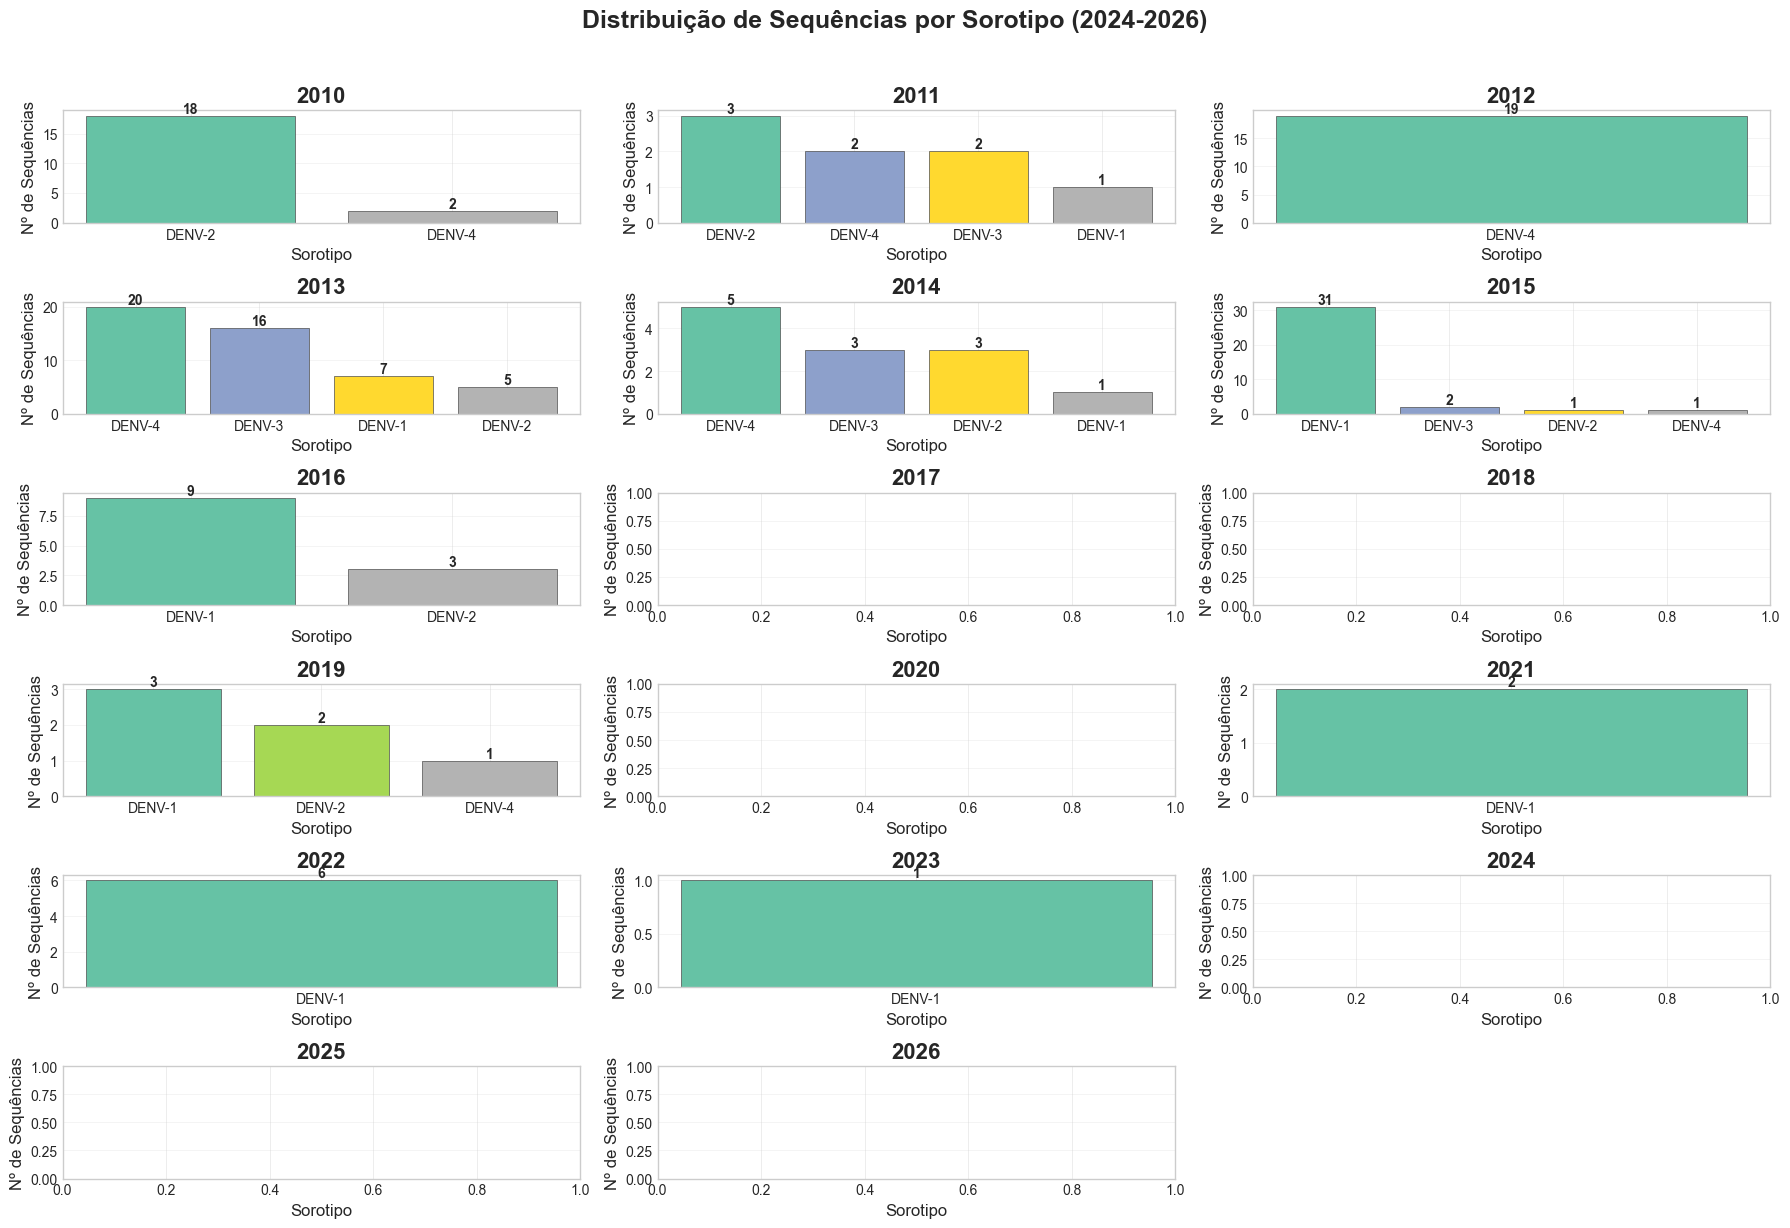

In [47]:
fig, axes = plt.subplots(1+len(years_to_fetch)//3, 3, figsize=(18, 12))
axes = axes.flatten()

years_to_fetch.sort()

for i, year in enumerate(years_to_fetch):
    ax = axes[i]
    yearly_data = metadata[metadata['year'] == year]
    serotype_counts = yearly_data['serotype'].value_counts()

    if not serotype_counts.empty:
        colors = plt.cm.Set2(np.linspace(0, 1, len(serotype_counts)))
        bars = ax.bar(
            serotype_counts.index, serotype_counts.values,
            color=colors, edgecolor='0.3', linewidth=0.5
        )
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold'
            )
    ax.set_title(f'{year}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Sorotipo', fontsize=12)
    ax.set_ylabel('Nº de Sequências', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].axis('off')
fig.suptitle(
    'Distribuição de Sequências por Sorotipo (2024-2026)',
    fontsize=18, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

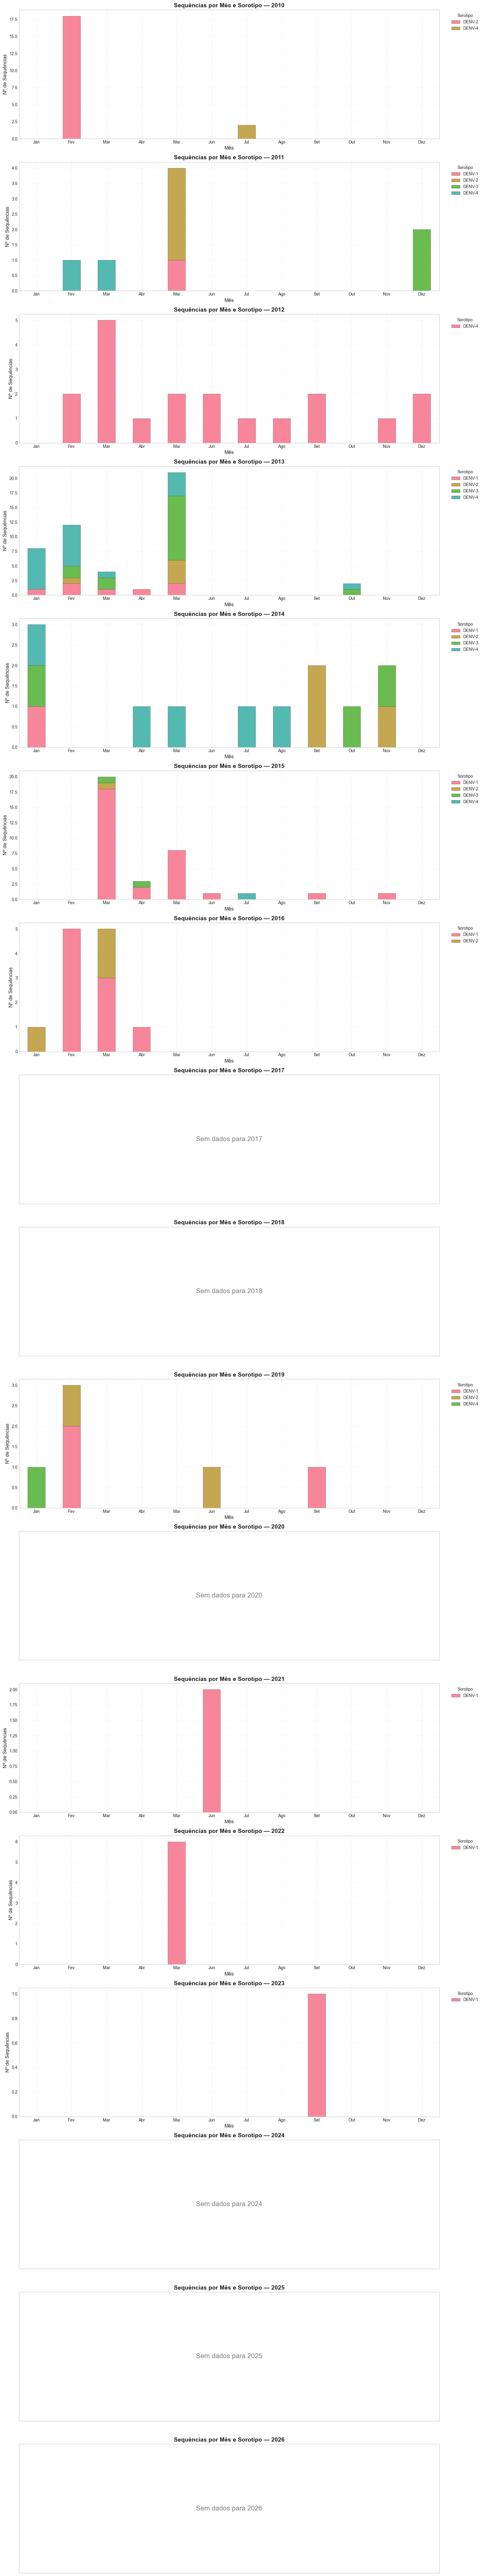

In [4]:
fig, axes = plt.subplots(len(years_to_fetch), 1, figsize=(16, 5 * len(years_to_fetch)), sharex=False)
if len(years_to_fetch) == 1:
    axes = [axes]

month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

for i, year in enumerate(years_to_fetch):
    ax = axes[i]
    yearly_data = metadata[metadata['year'] == year]
    monthly_serotype = (
        yearly_data.groupby(['month', 'serotype'])
        .size().unstack(fill_value=0)
    )

    if monthly_serotype.empty:
        ax.text(0.5, 0.5, f'Sem dados para {year}', transform=ax.transAxes,
                ha='center', va='center', fontsize=16, color='gray')
        ax.set_title(f'Sequências por Mês e Sorotipo — {year}', fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    monthly_serotype = monthly_serotype.reindex(range(1, 13), fill_value=0)
    monthly_serotype.plot(
        kind='bar', stacked=True, ax=ax, alpha=0.85, edgecolor='0.3', linewidth=0.5
    )
    ax.set_title(f'Sequências por Mês e Sorotipo — {year}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mês', fontsize=12)
    ax.set_ylabel('Nº de Sequências', fontsize=12)
    ax.set_xticklabels(month_labels, rotation=0)
    ax.legend(title='Sorotipo', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

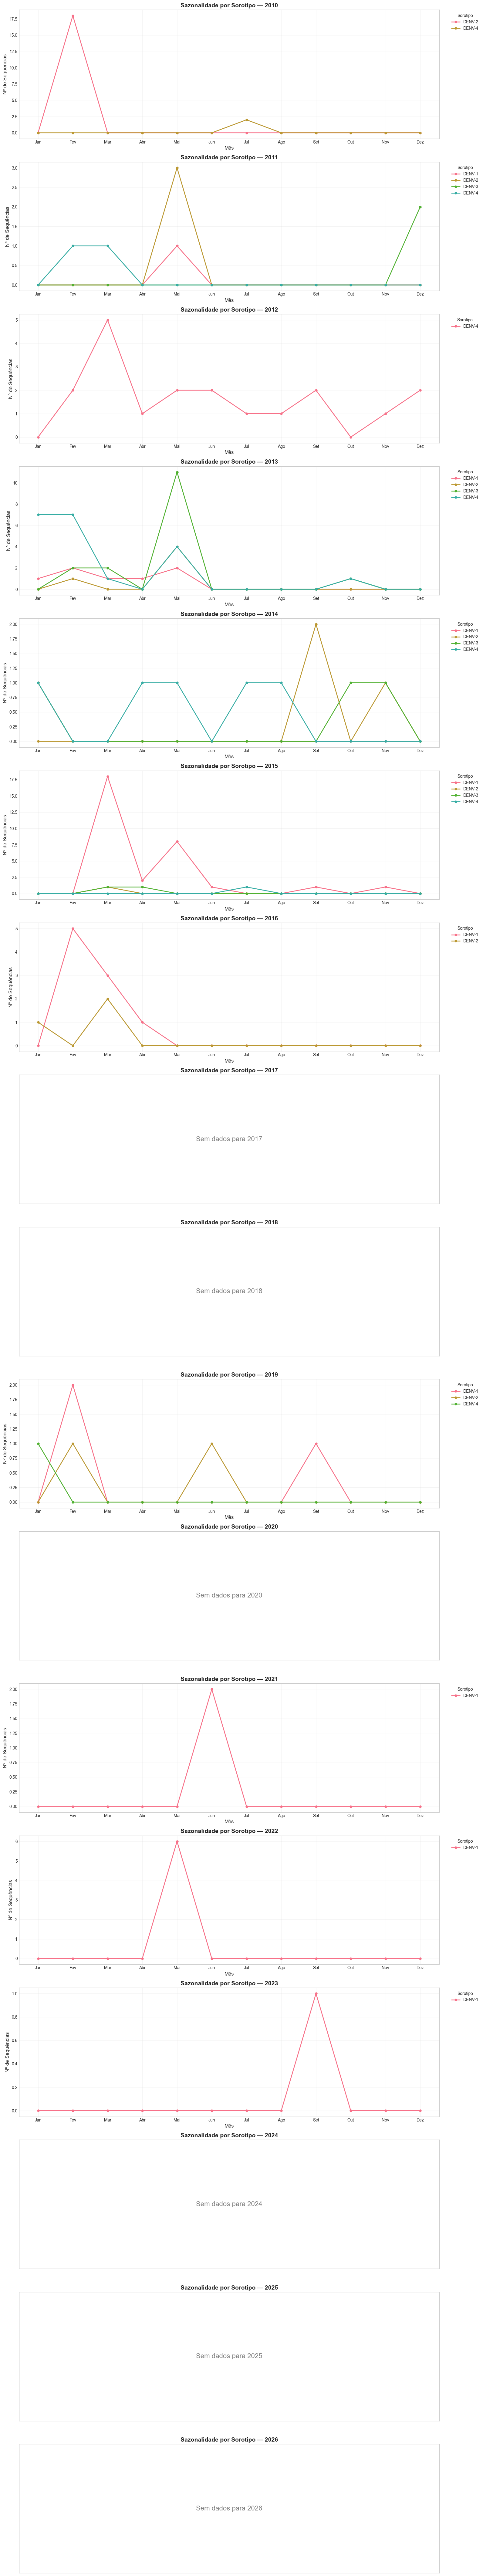

In [5]:
fig, axes = plt.subplots(len(years_to_fetch), 1, figsize=(16, 5 * len(years_to_fetch)), sharex=False)
if len(years_to_fetch) == 1:
    axes = [axes]

for i, year in enumerate(years_to_fetch):
    ax = axes[i]
    yearly_data = metadata[metadata['year'] == year]
    monthly_serotype = (
        yearly_data.groupby(['month', 'serotype'])
        .size().unstack(fill_value=0)
        .reindex(range(1, 13), fill_value=0)
    )

    if monthly_serotype.empty or monthly_serotype.sum().sum() == 0:
        ax.text(0.5, 0.5, f'Sem dados para {year}', transform=ax.transAxes,
                ha='center', va='center', fontsize=16, color='gray')
        ax.set_title(f'Sazonalidade por Sorotipo — {year}', fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    monthly_serotype.plot(kind='line', marker='o', linewidth=2, markersize=5, ax=ax)
    ax.set_title(f'Sazonalidade por Sorotipo — {year}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mês', fontsize=12)
    ax.set_ylabel('Nº de Sequências', fontsize=12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.legend(title='Sorotipo', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Proporção de Sorotipos por Ano

AttributeError: 'numpy.ndarray' object has no attribute 'pie'

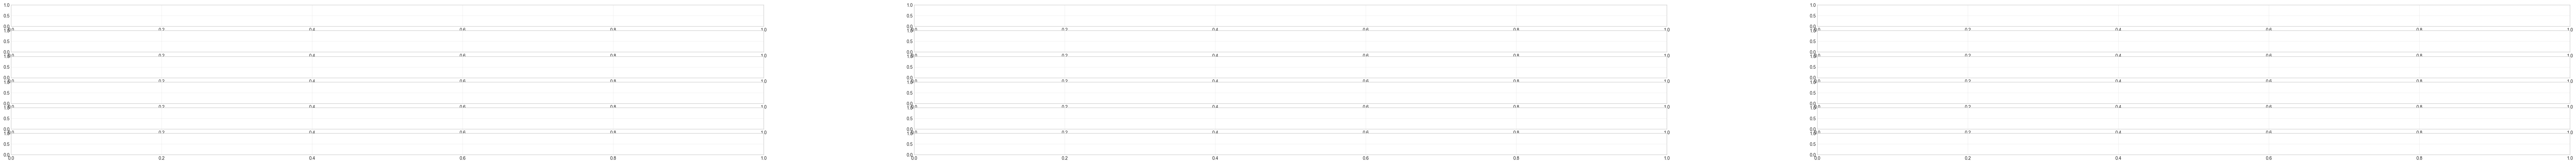

In [6]:
fig, axes = plt.subplots(1+ len(years_to_fetch)//3,3, figsize=(6 * len(years_to_fetch), 6))
if len(years_to_fetch) == 1:
    axes = [axes]

for i, year in enumerate(years_to_fetch):
    ax = axes[i]
    yearly_data = metadata[metadata['year'] == year]
    serotype_counts = yearly_data['serotype'].value_counts()

    if not serotype_counts.empty:
        colors = plt.cm.Set2(np.linspace(0, 1, len(serotype_counts)))
        wedges, texts, autotexts = ax.pie(
            serotype_counts.values,
            labels=serotype_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
        )
        for autotext in autotexts:
            autotext.set_fontweight('bold')
            autotext.set_fontsize(9)
    ax.set_title(f'{year} (n={len(yearly_data)})', fontsize=14, fontweight='bold')

fig.suptitle(
    'Proporção de Sorotipos por Ano',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 4. Distribuição Geográfica por Ano

In [ ]:
if 'geoLocAdmin1' in metadata.columns:
    fig, axes = plt.subplots(len(years_to_fetch), 1, figsize=(16, 7 * len(years_to_fetch)), sharex=False)
    if len(years_to_fetch) == 1:
        axes = [axes]

    for i, year in enumerate(years_to_fetch):
        ax = axes[i]
        yearly_data = metadata[metadata['year'] == year]
        state_analysis = yearly_data.groupby(['geoLocAdmin1', 'serotype']).size().unstack(fill_value=0)
        state_totals = state_analysis.sum(axis=1).sort_values(ascending=True)

        if not state_totals.empty:
            state_analysis.loc[state_totals.index].plot(
                kind='barh', stacked=True, ax=ax, alpha=0.85, edgecolor='0.3', linewidth=0.5
            )
        ax.set_title(f'Sequências por Estado e Sorotipo — {year}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Nº de Sequências', fontsize=12)
        ax.set_ylabel('')
        ax.legend(title='Sorotipo', loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print("\n📊 Total por estado e ano:")
    for year in years_to_fetch:
        yearly_data = metadata[metadata['year'] == year]
        state_counts = yearly_data['geoLocAdmin1'].value_counts().head(5)
        print(f"\n  {year}:")
        for state, count in state_counts.items():
            print(f"    {state}: {count}")

## 5. Mapas de Sequências por Sorotipo e Estado

In [ ]:
# Mapeamento de nomes de estados Pathoplexus -> siglas IBGE
state_name_to_abbr = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM',
    'Bahia': 'BA', 'Ceará': 'CE', 'Distrito Federal': 'DF', 'Espírito Santo': 'ES',
    'Goiás': 'GO', 'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS',
    'Minas Gerais': 'MG', 'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR',
    'Pernambuco': 'PE', 'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC',
    'São Paulo': 'SP', 'Sergipe': 'SE', 'Tocantins': 'TO'
}

if 'geoLocAdmin1' in metadata.columns:
    metadata['state_abbr'] = metadata['geoLocAdmin1'].map(state_name_to_abbr)
    metadata_valid = metadata.dropna(subset=['state_abbr'])
    print(f"Estados encontrados: {metadata_valid['state_abbr'].nunique()}")
    print(f"Estados sem correspondência: {metadata['geoLocAdmin1'][metadata['state_abbr'].isna()].unique()}")
else:
    print("Coluna geoLocAdmin1 não encontrada.")
    metadata_valid = metadata.copy()
    metadata_valid['state_abbr'] = None

In [ ]:
geojson_url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
br_states = gpd.read_file(geojson_url)
br_states = br_states.rename(columns={'sigla': 'state_abbr'})
print(f"GeoJSON carregado: {len(br_states)} estados")
print(f"Colunas: {br_states.columns.tolist()}")

In [ ]:
if 'state_abbr' in metadata_valid.columns and metadata_valid['state_abbr'].notna().any():
    serotype_state = (
        metadata_valid.groupby(['state_abbr', 'serotype'])
        .size().reset_index(name='count')
    )

    br_merged = br_states.merge(serotype_state, on='state_abbr', how='left')
    br_merged['count'] = br_merged['count'].fillna(0).astype(int)

    serotypes = sorted(br_merged['serotype'].dropna().unique())
    n_serotypes = len(serotypes)

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()

    for i, serotype in enumerate(serotypes):
        ax = axes[i]
        data = br_merged[br_merged['serotype'] == serotype]
        data.plot(
            column='count',
            cmap='YlOrRd',
            linewidth=0.4,
            edgecolor='0.8',
            legend=True,
            ax=ax,
            missing_kwds={'color': '#f0f0f0', 'edgecolor': '0.8', 'label': 'Sem dados'}
        )
        ax.set_title(f'{serotype}', fontsize=16, fontweight='bold')
        ax.axis('off')

        max_state = data.loc[data['count'].idxmax()]
        if max_state['count'] > 0:
            ax.annotate(
                f"{max_state['state_abbr']}: {int(max_state['count'])}",
                xy=(max_state.geometry.centroid.x, max_state.geometry.centroid.y),
                fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
            )

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(
        'Número de Sequências por Sorotipo de Dengue e Estado (Brasil)',
        fontsize=18, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    print("\n📊 Sequências por estado e sorotipo:")
    pivot = serotype_state.pivot(index='state_abbr', columns='serotype', values='count').fillna(0).astype(int)
    pivot['Total'] = pivot.sum(axis=1)
    print(pivot.sort_values('Total', ascending=False).to_string())

## 5.1. Mapa Interativo (Plotly)

In [ ]:
if 'state_abbr' in metadata_valid.columns and metadata_valid['state_abbr'].notna().any():
    br_geojson = json.loads(br_states[['state_abbr', 'geometry']].to_json())

    fig = px.choropleth_mapbox(
        br_merged,
        geojson=br_geojson,
        locations='state_abbr',
        featureidkey='properties.state_abbr',
        color='count',
        facet_col='serotype',
        facet_col_wrap=2,
        color_continuous_scale='YlOrRd',
        mapbox_style='carto-positron',
        zoom=3,
        center={"lat": -14, "lon": -51},
        opacity=0.85,
        labels={'count': 'Nº de Sequências'},
        title='<b>Sequências de Dengue por Sorotipo e Estado (Brasil)</b>'
    )

    fig.update_layout(
        margin={"r": 0, "t": 60, "l": 0, "b": 0},
        height=700,
    )

    fig.show()

## 6. Análise por Década

In [ ]:
# Análise por década
decade_analysis = metadata.groupby(['decade', 'serotype']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barras agrupadas
decade_analysis.plot(kind='bar', ax=ax1, alpha=0.8)
ax1.set_title('Sequências por Década e Sorotipo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Década', fontsize=12)
ax1.set_ylabel('Número de Sequências', fontsize=12)
ax1.legend(title='Sorotipo')
ax1.set_xticklabels([f"{int(x)}s" for x in decade_analysis.index], rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# Proporção por década
decade_pct = decade_analysis.div(decade_analysis.sum(axis=1), axis=0) * 100
decade_pct.plot(kind='bar', stacked=True, ax=ax2, alpha=0.8)
ax2.set_title('Proporção por Década (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Década', fontsize=12)
ax2.set_ylabel('Proporção (%)', fontsize=12)
ax2.legend(title='Sorotipo', bbox_to_anchor=(1.02, 1))
ax2.set_xticklabels([f"{int(x)}s" for x in decade_pct.index], rotation=0)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\n📊 Análise por década:")
print(decade_analysis.to_string())
print("\n📊 Proporção por década (%):")
print(decade_pct.round(1).to_string())

## 7. Resumo Estatístico

In [ ]:
print("="*70)
print("📊 RESUMO ESTATÍSTICO - DENGUE NO BRASIL (2024-2026)")
print("="*70)

print(f"\n📈 Geral:")
print(f"  Total de sequências: {len(metadata):,}")
print(f"  Período: {int(metadata['year'].min())}-{int(metadata['year'].max())}")
print(f"  Média por ano: {len(metadata) / metadata['year'].nunique():.0f} sequências")

print(f"\n🦠 Por Sorotipo:")
for st, count in metadata['serotype'].value_counts().items():
    pct = count / len(metadata) * 100
    print(f"  {st}: {count} sequências ({pct:.1f}%)")

print(f"\n📍 Por Estado (Top 5):")
if 'geoLocAdmin1' in metadata.columns:
    for state, count in metadata['geoLocAdmin1'].value_counts().head(5).items():
        pct = count / len(metadata) * 100
        print(f"  {state}: {count} ({pct:.1f}%)")

print(f"\n📅 Sequências por ano:")
for year in sorted(metadata['year'].dropna().unique()):
    count = len(metadata[metadata['year'] == year])
    print(f"  {int(year)}: {count} sequências")

print("="*70)

## 8. Exportar Dados

In [ ]:
# Exportar dados processados
output_file = "pathoplexus_dengue_brasil_2024_2026.csv"
metadata.to_csv(output_file, index=False)
print(f"✅ Dados exportados para: {output_file}")

from pathlib import Path
file_size = Path(output_file).stat().st_size / 1024
print(f"📁 Tamanho: {file_size:.2f} KB")
print(f"📊 Registros: {len(metadata)}")
print(f"📅 Período: {metadata['year'].min()}-{metadata['year'].max()}")

## Conclusões

Este notebook demonstrou a análise de dados genômicos recentes da dengue no Brasil (2024-2026) a partir do Pathoplexus.

### 🎯 Principais Descobertas

1. **Cobertura Temporal:** Dados genômicos de 3 anos recentes, permitindo análise de tendências atuais

2. **Distribuição de Sorotipos:**
   - Comparação da prevalência relativa de cada sorotipo entre 2024, 2025 e 2026
   - Padrões sazonais distintos por sorotipo

3. **Padrões Sazonais:** Distribuição mensal das sequências revela picos de coleta
   alinhados com a temporada de dengue no Brasil (jan-mai)

4. **Cobertura Geográfica:** Distribuição estadual das amostras sequenciadas,
   com mapas coropléticos por sorotipo

### 💡 Aplicações

- **Vigilância Genômica:** Monitoramento em tempo real dos sorotipos em circulação
- **Saúde Pública:** Informação para políticas de controle da dengue
- **Evolução Viral:** Identificação de mudanças na dominância de sorotipos

### 📚 Recursos

- Pathoplexus: https://pathoplexus.org/
- API LAPIS: https://lapis.pathoplexus.org/
- Acessor: `scripts/accessors/pathoplexus.py`